# NCAD-CS v4: Anomaly Detection Protocol on Creditcard Intrusion Detection Dataset (SSM Encoder)

This notebook applies the Counterfactual Successor Memory (NCAD-CS v4) model to the multivariate Creditcard network intrusion detection dataset (subset 0).

### Protocol Highlights:
1. **Preventing Data Leakage**: Features are selected and standardizer statistics (mean, std) are fitted **exclusively on the training split**, then used to transform validation and test sets.
2. **Highly Multivariate Scaling**: Rather than extracting computationally intensive univariate time-series features for all 73 dimensions, the notebook directly scales and utilizes the raw numeric packet flow features, dropping zero-variance features to prevent division-by-zero.
3. **Performance-Optimized Windowing**: With 400k+ test steps, a stride of `step=10` is used to create sequence windows. This reduces memory and computation requirements by 10x while maintaining contiguous coverage for point-level prediction.
4. **Threshold Calibration**: We compare the unsupervised adaptive elbow threshold with validation-set optimization.
5. **Evaluation**: POINT-level anomaly metrics (Precision, Recall, F1, TP/FP) are evaluated on the test set.


In [1]:
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

# Resolve project root path dynamically
project_root = Path.cwd().resolve()
while not (project_root / 'mTSBench_data').exists() and project_root != project_root.parent:
    project_root = project_root.parent

print(f"Project root identified as: {project_root}")

# Add required paths to sys.path to access local packages
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
if str(project_root / 'notebooks_v4') not in sys.path:
    sys.path.insert(0, str(project_root / 'notebooks_v4'))

# Import NCAD modules
from src.models.anomaly_injector import AnomalyInjectionConfig, ContextualAnomalyInjector
from src.models.tcn_encoder import contrastive_loss
from src.models.selective_ssm_encoder import SelectiveSSMContextEncoder
from src.models.successor_memory import CounterfactualSuccessorMemory, SuccessorMemoryConfig
from src.utils.event_fusion import (
    adaptive_elbow_score_floor,
    aggregate_window_scores,
    compute_metrics,
    event_level_filter,
    fuse_evidence_scores,
    local_deviation_scores,
    moving_average,
    percentile_score_floor,
    positive_robust_z,
    reconstruction_deviation_scores,
    robust_dispersion_floor,
    robust_stats,
    dispersion_confidence,
    successor_manifold_uncertainty_scores,
)
from src.data.data_loader import DataLoader

# Setup device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device for model execution: {device}")
print("NCAD modules loaded successfully.")


Project root identified as: C:\Users\andre\OneDrive\Desktop\NCAD_CS
Device for model execution: cuda
NCAD modules loaded successfully.


In [2]:
# Define paths to Creditcard data files
creditcard_dir = project_root / 'mTSBench_data' / 'creditcard'
train_path = creditcard_dir / 'creditcard_train.csv'
val_path = creditcard_dir / 'creditcard_val.csv'
test_path = creditcard_dir / 'creditcard_test.csv'

# Load dataframes
train_df = pd.read_csv(train_path)
val_df = pd.read_csv(val_path)
test_df = pd.read_csv(test_path)

print(f"Loaded datasets successfully.")
print(f"Train Shape: {train_df.shape} (Anomalies: {train_df['is_anomaly'].sum()})")
print(f"Val Shape:   {val_df.shape} (Anomalies: {val_df['is_anomaly'].sum()})")
print(f"Test Shape:  {test_df.shape} (Anomalies: {test_df['is_anomaly'].sum()})")


Loaded datasets successfully.
Train Shape: (56804, 31) (Anomalies: 0)
Val Shape:   (56961, 31) (Anomalies: 84)
Test Shape:  (170885, 31) (Anomalies: 251)


### Step 1: Feature Scaling without Data Leakage
We identify numeric columns and drop constant (zero variance) columns fitted on training split to prevent division-by-zero errors.
A `StandardScaler` is fitted **exclusively on the training split**, and applied to scale the train, validation, and test datasets. This prevents test set leakage.


In [3]:
from sklearn.preprocessing import StandardScaler

# Identify numeric features and drop target
numeric_cols = train_df.select_dtypes(include='number').columns.tolist()
if 'is_anomaly' in numeric_cols:
    numeric_cols.remove('is_anomaly')

# Drop constant features based on train set variance
constant_cols = [c for c in numeric_cols if train_df[c].std() == 0]
feature_cols = [c for c in numeric_cols if c not in constant_cols]

print(f"Total numeric features found: {len(numeric_cols)}")
print(f"Constant features dropped:     {len(constant_cols)}")
print(f"Active features for training:  {len(feature_cols)}")

# Fit scaler ONLY on train set
scaler = StandardScaler()
scaler.fit(train_df[feature_cols])

# Transform datasets
train_scaled = scaler.transform(train_df[feature_cols])
val_scaled = scaler.transform(val_df[feature_cols])
test_scaled = scaler.transform(test_df[feature_cols])

print("Data scaling complete.")


Total numeric features found: 29
Constant features dropped:     0
Active features for training:  29
Data scaling complete.


### Step 2: Creating Sliding Windows
We construct sequence windows of size `context_size + suspect_size` ($300$ steps total).
Because the datasets are large (up to 400k rows in test), we use a sliding step size of `step = 10` to reduce memory and computation by 10x while maintaining prediction coverage.


In [4]:
context_size = 9
suspect_size = 1
window_size = context_size + suspect_size
step = 1

# Create sliding windows
train_windows = DataLoader.create_windows(train_scaled, window_size, step)
val_windows = DataLoader.create_windows(val_scaled, window_size, step)
test_windows = DataLoader.create_windows(test_scaled, window_size, step)

print(f"Train windows shape: {train_windows.shape}")
print(f"Val windows shape:   {val_windows.shape}")
print(f"Test windows shape:  {test_windows.shape}")


Train windows shape: (56795, 10, 29)
Val windows shape:   (56952, 10, 29)
Test windows shape:  (170876, 10, 29)


### Step 3: Contrastive Training of SSM Encoder
We train the `SelectiveSSMContextEncoder` model to map features to a 16-dimensional embedding space using contrastive loss and on-the-fly synthetic anomaly injection.
10% of the training windows are reserved for early stopping validation.


In [5]:
import torch.optim as optim

def split_train_validation(windows, val_split=0.1, seed=42):
    rng = np.random.default_rng(seed)
    indices = np.arange(len(windows))
    rng.shuffle(indices)
    n_val = int(len(indices) * val_split)
    return windows[indices[n_val:]], windows[indices[:n_val]]

# Hyperparameters (aligned with CICIDS reference protocol)
epochs = 5  # Large dataset; scheduler + early stopping handle convergence
batch_size = 32
learning_rate = 1e-3
weight_decay = 1e-4
margin = 1.0
val_split = 0.1
patience = 3
seed = 42
injection_ratio = 0.5
latent_dim = 64

# Set seeds
np.random.seed(seed)
torch.manual_seed(seed)

# Split training windows
training_data, val_data = split_train_validation(train_windows, val_split, seed)

# Instantiate Selective SSM Encoder (GRU-backed)
input_dim = len(feature_cols)
model = SelectiveSSMContextEncoder(
    input_dim=input_dim,
    latent_dim=latent_dim,
    hidden_dim=64,
    layers=2,
    dropout=0.25
)
model = model.to(device)

optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

# Share injector seed across train/val so val loss is directly comparable to train loss
injector = ContextualAnomalyInjector(AnomalyInjectionConfig(injection_ratio=injection_ratio), seed=seed)
val_injector = ContextualAnomalyInjector(AnomalyInjectionConfig(injection_ratio=injection_ratio), seed=seed)

# Pre-generate a FIXED injected validation set so val_loss is deterministic across epochs
val_clean_list, val_modified_list, val_label_list = [], [], []
for batch_start in range(0, len(val_data), batch_size):
    clean_batch = val_data[batch_start : batch_start + batch_size]
    modified_batch, labels = val_injector.inject_batch(clean_batch, context_size)
    val_clean_list.append(clean_batch)
    val_modified_list.append(modified_batch)
    val_label_list.append(labels)

best_state = None
best_val_loss = float("inf")
patience_counter = 0

train_losses = []
val_losses = []

print("Starting SSM Encoder training...")
for epoch in range(1, epochs + 1):
    model.train()
    epoch_indices = np.random.permutation(len(training_data))
    total_train_loss = 0.0
    total_count = 0

    for batch_start in range(0, len(epoch_indices), batch_size):
        batch_indices = epoch_indices[batch_start : batch_start + batch_size]
        clean_batch = training_data[batch_indices]
        modified_batch, labels = injector.inject_batch(clean_batch, context_size)

        full_tensor = torch.from_numpy(modified_batch).float().to(device)
        context_tensor = torch.from_numpy(clean_batch[:, :context_size]).float().to(device)
        label_tensor = torch.from_numpy(labels).float().to(device)

        optimizer.zero_grad(set_to_none=True)
        loss = contrastive_loss(model(full_tensor), model(context_tensor), label_tensor, margin=margin)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_train_loss += float(loss.item()) * len(clean_batch)
        total_count += len(clean_batch)

    train_loss = total_train_loss / total_count

    # Validation evaluation on fixed injected set
    model.eval()
    total_val_loss = 0.0
    val_count = 0
    with torch.no_grad():
        for clean_batch, modified_batch, labels in zip(val_clean_list, val_modified_list, val_label_list):
            full_tensor = torch.from_numpy(modified_batch).float().to(device)
            context_tensor = torch.from_numpy(clean_batch[:, :context_size]).float().to(device)
            label_tensor = torch.from_numpy(labels).float().to(device)

            loss = contrastive_loss(model(full_tensor), model(context_tensor), label_tensor, margin=margin)
            total_val_loss += float(loss.item()) * len(clean_batch)
            val_count += len(clean_batch)

    val_loss = total_val_loss / max(val_count, 1)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]["lr"]

    print(f"  Epoch {epoch:02d}/{epochs}: train_loss={train_loss:.5f}, val_loss={val_loss:.5f}, lr={current_lr:.2e}")

    if val_loss < best_val_loss - 1e-5:
        best_val_loss = val_loss
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"  Early stopping triggered after {epoch} epochs.")
            break

if best_state is not None:
    model.load_state_dict(best_state)
print(f"SSM Encoder training complete. Best val_loss={best_val_loss:.5f}")


Starting SSM Encoder training...
  Epoch 01/5: train_loss=0.30809, val_loss=0.19192, lr=1.00e-03
  Epoch 02/5: train_loss=0.13638, val_loss=0.16386, lr=1.00e-03
  Epoch 03/5: train_loss=0.12372, val_loss=0.14621, lr=1.00e-03
  Epoch 04/5: train_loss=0.12104, val_loss=0.14137, lr=1.00e-03
  Epoch 05/5: train_loss=0.11941, val_loss=0.13746, lr=1.00e-03
SSM Encoder training complete. Best val_loss=0.13746


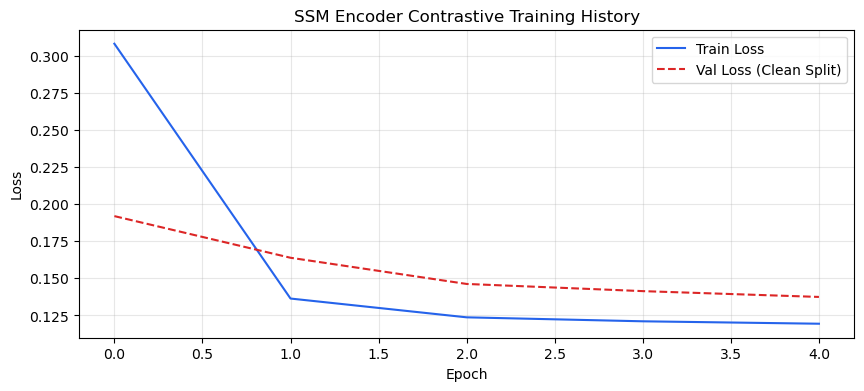

In [6]:
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label="Train Loss", color="#2563eb", linewidth=1.5)
plt.plot(val_losses, label="Val Loss (Clean Split)", color="#dc2626", linestyle="--", linewidth=1.5)
plt.title("SSM Encoder Contrastive Training History")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### Step 4: Counterfactual Successor Memory and Scoring
We fit the `CounterfactualSuccessorMemory` on the SSM embeddings of the normal training windows.
To handle multivariate data efficiently, we define a multivariate local deviation scorer that checks multiple representative features, then query the memory to score validation and test windows.


In [7]:
def encode_windows(model, windows, batch_size=32):
    model.eval()
    embeddings = []
    with torch.no_grad():
        for start in range(0, len(windows), batch_size):
            batch = torch.from_numpy(windows[start : start + batch_size]).float().to(device)
            embeddings.append(model(batch).cpu().numpy())
    return np.concatenate(embeddings, axis=0).astype(np.float32)

# Encode training contexts; keep RAW successors so reconstruction component
# remains meaningful in the original feature space (point-anomaly target).
train_contexts = train_windows[:, :context_size]
train_successors = train_windows[:, context_size:]
train_context_embeddings = encode_windows(model, train_contexts)

# Instantiate and fit successor memory
memory = CounterfactualSuccessorMemory(
    SuccessorMemoryConfig(n_neighbors=8, max_memory_windows=5000, context_percentile=99.0, seed=42)
)
memory.fit(train_context_embeddings, train_successors)
print(f"Fitted Successor Memory with {len(memory.context_embeddings)} windows.")

# Multivariate Local Deviation Scorer — fully vectorized across ALL features.
def local_deviation_scores_multivariate(windows, context_size, tail_size=64, chunk_size=2048):
    n_windows = windows.shape[0]
    out = np.empty(n_windows, dtype=np.float32)
    tail_start = max(0, context_size - tail_size)
    for start in range(0, n_windows, chunk_size):
        end = min(start + chunk_size, n_windows)
        chunk = np.asarray(windows[start:end], dtype=np.float64)            # (B, T, F)
        context_tail = chunk[:, tail_start:context_size, :]                  # (B, Tc, F)
        suspects = chunk[:, context_size:, :]                                # (B, Ts, F)
        medians = np.median(context_tail, axis=1)                            # (B, F)
        mad = np.median(np.abs(context_tail - medians[:, None, :]), axis=1)  # (B, F)
        scale = np.maximum(1.4826 * mad, 1e-4)                               # (B, F)
        diff = (suspects - medians[:, None, :]) / scale[:, None, :]          # (B, Ts, F)
        point_z = np.max(np.abs(diff), axis=1)                               # (B, F)
        mean_shift = np.abs(np.mean(suspects, axis=1) - medians) / scale     # (B, F)
        per_feature = np.maximum(point_z, mean_shift)                        # (B, F)
        out[start:end] = np.max(per_feature, axis=1).astype(np.float32)
    return out

score_diagnostics = {}

def compute_anomaly_scores(windows, dataset_name):
    print(f"Computing anomaly scores for {dataset_name} set...")

    # 1. Calibration stats from training memory
    train_local_scores = local_deviation_scores_multivariate(train_windows, context_size, tail_size=64)
    calibration_local_scores = train_local_scores[memory.sample_indices]

    # Reconstruction calibration
    train_recon_scores = reconstruction_deviation_scores(
        train_successors[memory.sample_indices],
        memory.calibration_expected_successors
    )

    successor_stats = robust_stats(memory.calibration_successor_scores)
    local_stats = robust_stats(calibration_local_scores)
    recon_stats = robust_stats(train_recon_scores)

    # 2. Query Successor Memory for the target dataset
    contexts = windows[:, :context_size]
    observed_successors = windows[:, context_size:]
    context_embeddings = encode_windows(model, contexts)
    query = memory.query(context_embeddings, observed_successors)

    # 3. Compute component robust Z-scores
    local_raw_scores = local_deviation_scores_multivariate(windows, context_size, tail_size=64)
    successor_z = positive_robust_z(query.successor_scores, successor_stats)
    local_z = positive_robust_z(local_raw_scores, local_stats)

    # Reconstruction deviation
    recon_raw = reconstruction_deviation_scores(observed_successors, query.expected_successors)
    recon_z = positive_robust_z(recon_raw, recon_stats)

    if float(memory.context_threshold) <= 1e-6:
        context_ratio = np.ones_like(query.context_distances, dtype=np.float32)
    else:
        context_ratio = query.context_distances / float(memory.context_threshold)
    # Cap context_ratio so a single latent excursion cannot drown the other components.
    context_ratio = np.minimum(context_ratio, 3.0).astype(np.float32)

    # 4. Multi-signal fusion scoring (creditcard-specific weights with reconstruction)
    window_scores = fuse_evidence_scores(
        successor_z=successor_z,
        local_z=local_z,
        context_ratio=context_ratio,
        reconstruction_z=recon_z,
        successor_weight=1.0,
        local_weight=0.80,
        context_weight=0.35,
        reconstruction_weight=0.60,
    )
    score_diagnostics[dataset_name] = {
        "window_scores": window_scores,
        "successor_z": successor_z,
        "local_z": local_z,
        "context_ratio": context_ratio,
        "reconstruction_z": recon_z,
        "successor_raw": query.successor_scores,
        "local_raw": local_raw_scores,
        "context_distances": query.context_distances,
    }
    return window_scores

# Compute window-level scores
val_window_scores = compute_anomaly_scores(val_windows, "Validation")
test_window_scores = compute_anomaly_scores(test_windows, "Test")


Fitted Successor Memory with 5000 windows.
Computing anomaly scores for Validation set...
Computing anomaly scores for Test set...


### Step 5: Point-level Score Aggregation and Smoothing
We aggregate window-level anomaly scores back to point-level sequences using `aggregate_window_scores` and smooth the curves via moving average.


In [8]:
smoothing_window = 1

def process_point_scores(window_scores, raw_len):
    # Aggregate window-level scores to point-level
    point_scores, valid_mask = aggregate_window_scores(
        window_scores,
        n_points=raw_len,
        context_size=context_size,
        suspect_size=suspect_size,
        step=step,
        reducer="mean",
        mapping_method="middle"
    )
    # Smooth point-level scores
    smoothed = moving_average(point_scores, smoothing_window)
    return smoothed, valid_mask

val_scores, val_mask = process_point_scores(val_window_scores, len(val_df))
test_scores, test_mask = process_point_scores(test_window_scores, len(test_df))

print(f"Validation point scores shape: {val_scores.shape}")
print(f"Test point scores shape:       {test_scores.shape}")


Validation point scores shape: (56961,)
Test point scores shape:       (170885,)


### Step 6: Threshold Calibration
We establish decision thresholds using two approaches on validation split:
1. **Unsupervised Adaptive Elbow Floor**: The consensus threshold derived from validation set anomaly scores without using labels.
2. **Supervised Optimization**: Grid search on validation scores to optimize the F1-score with respect to labels.


In [9]:
# Strategy 1: Unsupervised Adaptive Elbow Threshold
val_valid_scores = val_scores[val_mask]
floor_res = adaptive_elbow_score_floor(val_valid_scores)
unsupervised_threshold = floor_res.threshold
print(f"Unsupervised Adaptive Elbow Threshold: {unsupervised_threshold:.5f} (Selected candidate: {floor_res.selected_candidate})")

# Strategy 2: Supervised Validation Set Tuning (Maximize F1)
val_labels = val_df['is_anomaly'].to_numpy()
best_f1 = 0.0
best_threshold = 0.0
threshold_sweep_records = []

# Single linspace sweep (5th to 99.9th percentile) — same protocol as CICIDS/CalIt2.
candidates = np.linspace(
    np.percentile(val_valid_scores, 5.0),
    np.percentile(val_valid_scores, 99.9),
    300,
)
# Use STANDARD (non-PA) F1 for the sweep: PA-F1 rewards single-point hits in
# long anomaly segments, which can drive the optimum down to a near-zero
# threshold that flags nearly every point on test.
for th in candidates:
    preds = event_level_filter(val_scores, th, val_mask, min_run=1, extreme_factor=1.75)
    metrics = compute_metrics(val_labels, preds, valid_mask=val_mask, use_pa=False)
    threshold_sweep_records.append({
        "threshold": th,
        "precision": metrics.get("precision", 0.0),
        "recall": metrics.get("recall", 0.0),
        "f1": metrics.get("f1", 0.0),
        "tp": metrics.get("tp", 0),
        "fp": metrics.get("fp", 0),
        "fn": metrics.get("fn", 0),
    })
    if metrics.get('f1', 0.0) > best_f1:
        best_f1 = metrics['f1']
        best_threshold = th

threshold_sweep_df = pd.DataFrame(threshold_sweep_records)
print(f"Supervised Validation Optimized Threshold: {best_threshold:.5f} (Validation F1-score: {best_f1:.4f})")

if abs(best_threshold - candidates[0]) < 1e-9:
    print("WARNING: best threshold at LOWER sweep bound; consider lowering the floor further.")
elif abs(best_threshold - candidates[-1]) < 1e-9:
    print("WARNING: best threshold at UPPER sweep bound; consider raising the ceiling.")


Unsupervised Adaptive Elbow Threshold: 5.50000 (Selected candidate: otsu)
Supervised Validation Optimized Threshold: 17.00098 (Validation F1-score: 0.0851)


### Step 7: Test Set Evaluation
We evaluate both the unsupervised threshold and the validation-optimized threshold on the unseen Test dataset, computing standard classification metrics (Precision, Recall, F1, Conf Matrix).


In [10]:
from sklearn.metrics import average_precision_score, roc_auc_score

test_labels = test_df['is_anomaly'].to_numpy()
valid_test_bool = test_mask.astype(bool)

# Threshold-free ranking metrics (independent of any threshold choice).
test_scores_valid = test_scores[valid_test_bool]
test_labels_valid = test_labels[valid_test_bool]
pr_auc = average_precision_score(test_labels_valid, test_scores_valid)
roc_auc = roc_auc_score(test_labels_valid, test_scores_valid)
base_rate = float(test_labels_valid.mean())
print(f"Threshold-free metrics on test set:")
print(f"  PR-AUC (Average Precision): {pr_auc:.4f}   (base rate / random baseline = {base_rate:.4f})")
print(f"  ROC-AUC:                    {roc_auc:.4f}   (random baseline = 0.5)")

# Apply the validation-optimized threshold DIRECTLY on test scores: val and test
# scores come from the same pipeline so the threshold lives on the same scale.
test_opt_threshold = float(best_threshold)
print(f"\nApplying validation-optimized threshold directly to test: {test_opt_threshold:.5f}")

# Creditcard: point anomalies, so min_run=1
min_run_val = 1

for name, threshold in [("Unsupervised Adaptive Elbow", unsupervised_threshold), ("Validation Set Optimized", test_opt_threshold)]:
    # Apply event-level filtering
    preds = event_level_filter(test_scores, threshold, test_mask, min_run=min_run_val, extreme_factor=1.75)
    preds = preds * test_mask.astype(np.float32)

    # Compute standard and Point-Adjusted metrics
    metrics_std = compute_metrics(test_labels, preds, valid_mask=test_mask, use_pa=False)
    metrics_pa = compute_metrics(test_labels, preds, valid_mask=test_mask, use_pa=True)

    print(f"\n=== Test Set Evaluation: {name} Threshold ({threshold:.5f}) ===")
    print("Standard (Without Point-Adjustment):")
    print(f"  Precision:        {metrics_std.get('precision', 0.0):.4f}")
    print(f"  Recall:           {metrics_std.get('recall', 0.0):.4f}")
    print(f"  F1-Score:         {metrics_std.get('f1', 0.0):.4f}")
    print(f"  Confusion Matrix: TP={metrics_std.get('tp')}, TN={metrics_std.get('tn')}, FP={metrics_std.get('fp')}, FN={metrics_std.get('fn')}")
    print("With Point-Adjustment (PA):")
    print(f"  Precision:        {metrics_pa.get('precision', 0.0):.4f}")
    print(f"  Recall:           {metrics_pa.get('recall', 0.0):.4f}")
    print(f"  F1-Score:         {metrics_pa.get('f1', 0.0):.4f}")
    print(f"  Confusion Matrix: TP={metrics_pa.get('tp')}, TN={metrics_pa.get('tn')}, FP={metrics_pa.get('fp')}, FN={metrics_pa.get('fn')}")


Threshold-free metrics on test set:
  PR-AUC (Average Precision): 0.0884   (base rate / random baseline = 0.0015)
  ROC-AUC:                    0.9365   (random baseline = 0.5)

Applying validation-optimized threshold directly to test: 17.00098

=== Test Set Evaluation: Unsupervised Adaptive Elbow Threshold (5.50000) ===
Standard (Without Point-Adjustment):
  Precision:        0.0218
  Recall:           0.7052
  F1-Score:         0.0422
  Confusion Matrix: TP=177, TN=162665, FP=7960, FN=74
With Point-Adjustment (PA):
  Precision:        0.0219
  Recall:           0.7092
  F1-Score:         0.0424
  Confusion Matrix: TP=178, TN=162665, FP=7960, FN=73

=== Test Set Evaluation: Validation Set Optimized Threshold (17.00098) ===
Standard (Without Point-Adjustment):
  Precision:        0.1688
  Recall:           0.2112
  F1-Score:         0.1876
  Confusion Matrix: TP=53, TN=170364, FP=261, FN=198
With Point-Adjustment (PA):
  Precision:        0.1792
  Recall:           0.2271
  F1-Score:  

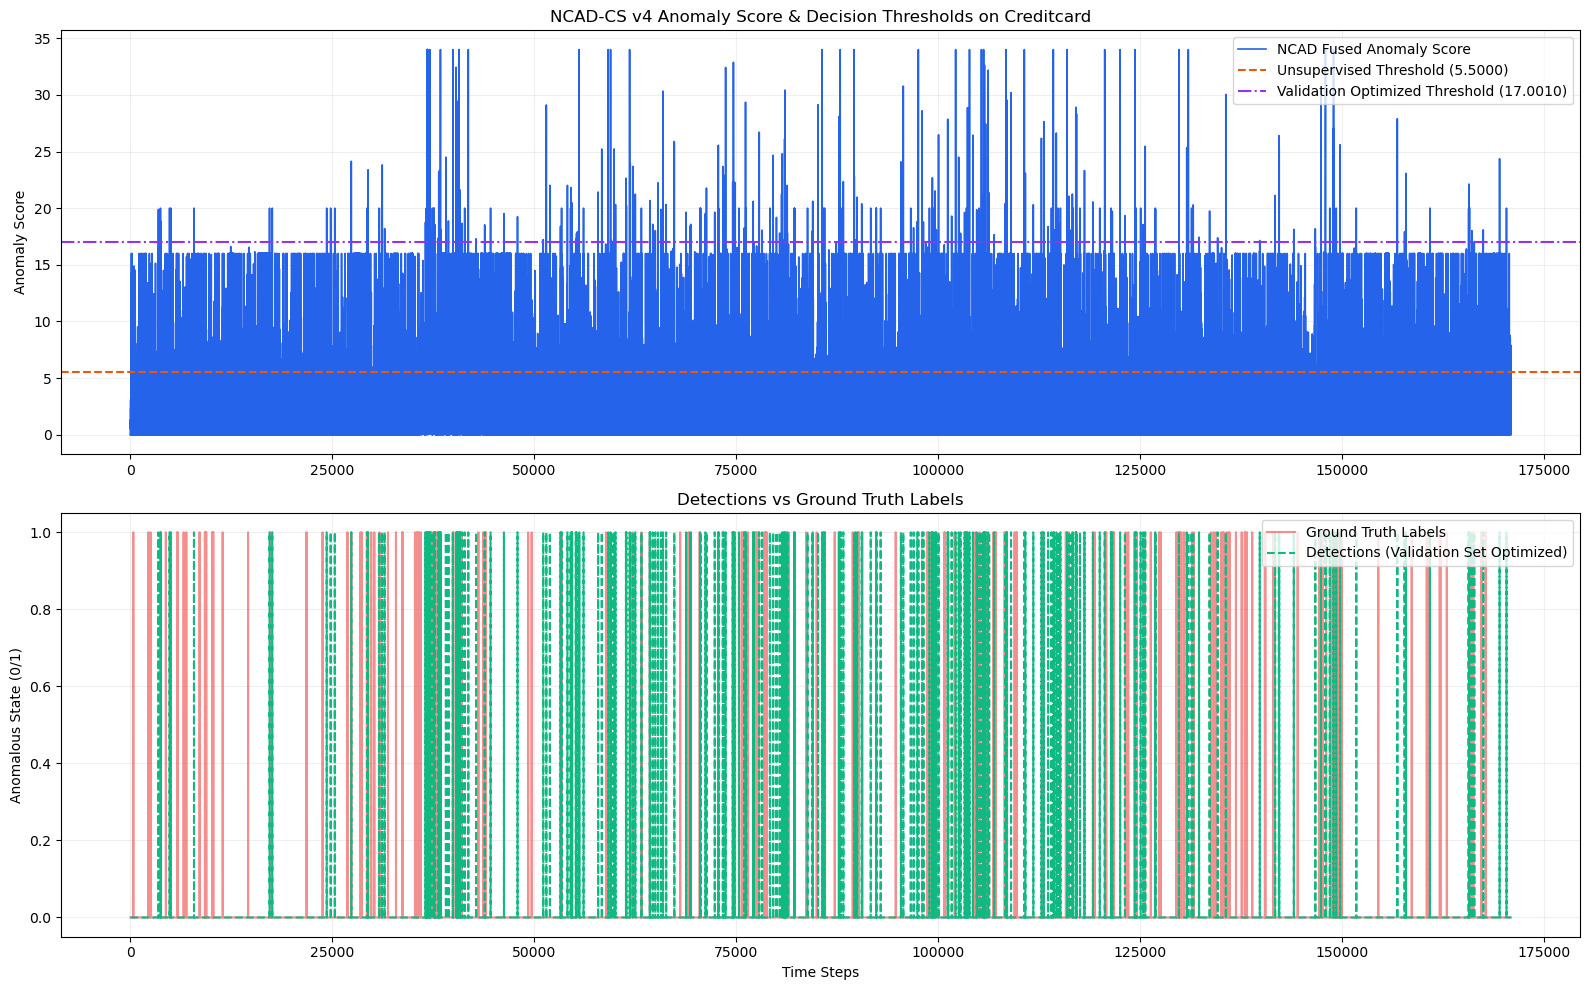

In [11]:
plt.figure(figsize=(16, 10))

# Plot 1: Anomaly Scores and Calibration Thresholds
plt.subplot(2, 1, 1)
plt.plot(test_scores, label="NCAD Fused Anomaly Score", color="#2563eb", linewidth=1.2)
plt.axhline(unsupervised_threshold, color="#ea580c", linestyle="--", label=f"Unsupervised Threshold ({unsupervised_threshold:.4f})")
plt.axhline(test_opt_threshold, color="#9333ea", linestyle="-.", label=f"Validation Optimized Threshold ({test_opt_threshold:.4f})")
plt.ylabel("Anomaly Score")
plt.title("NCAD-CS v4 Anomaly Score & Decision Thresholds on Creditcard")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.2)

# Plot 2: Model Predictions vs Ground Truth Labels
plt.subplot(2, 1, 2)
opt_preds = event_level_filter(test_scores, test_opt_threshold, test_mask, min_run=min_run_val, extreme_factor=1.75)
plt.plot(test_labels, label="Ground Truth Labels", color="#ef4444", linewidth=1.5, alpha=0.6)
plt.plot(opt_preds, label="Detections (Validation Set Optimized)", color="#10b981", linestyle="--", linewidth=1.5)
plt.ylabel("Anomalous State (0/1)")
plt.xlabel("Time Steps")
plt.title("Detections vs Ground Truth Labels")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()
